Step 10.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Step 10.2 Load Test Data

In [2]:
X_test = pd.read_csv(
    "../data/processed/X_test_processed.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTarget distribution:")
print(y_test.value_counts())

X_test shape: (1000, 30)
y_test shape: (1000,)

Target distribution:
Fraudulent
0    904
1     96
Name: count, dtype: int64


Step 10.3 Load Logistic Regression

In [3]:
logistic_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

print("Logistic Regression loaded successfully.")

Logistic Regression loaded successfully.


Step 10.4 Load Random Forest

In [4]:
random_forest_model = joblib.load(
    "../models/random_forest_model.pkl"
)

print("Random Forest loaded successfully.")

Random Forest loaded successfully.


Step 10.5 Generate Fraud Probabilities

In [5]:
logistic_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

rf_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]

print("Logistic probability range:")
print(logistic_prob.min(), "to", logistic_prob.max())

print("\nRandom Forest probability range:")
print(rf_prob.min(), "to", rf_prob.max())

Logistic probability range:
0.12535620250960464 to 0.9920242797652298

Random Forest probability range:
0.05847044352108844 to 0.870397853816832


Step 10.6 Evaluate Default Threshold 0.50

In [6]:
threshold = 0.50

logistic_pred = (
    logistic_prob >= threshold
).astype(int)

rf_pred = (
    rf_prob >= threshold
).astype(int)

Step 10.7 Logistic Regression at 0.50

In [7]:
logistic_metrics = {
    "Model": "Logistic Regression",
    "Threshold": threshold,
    "Accuracy": accuracy_score(
        y_test,
        logistic_pred
    ),
    "Precision": precision_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_prob
    )
}

pd.DataFrame([logistic_metrics])

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5,0.87,0.39375,0.65625,0.492188,0.799514


Step 10.8 Random Forest at 0.50

In [8]:
rf_metrics = {
    "Model": "Random Forest",
    "Threshold": threshold,
    "Accuracy": accuracy_score(
        y_test,
        rf_pred
    ),
    "Precision": precision_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        rf_prob
    )
}

pd.DataFrame([rf_metrics])

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.5,0.894,0.451923,0.489583,0.47,0.799387


Step 10.9 Threshold Analysis Function

In [9]:
def evaluate_thresholds(
    y_true,
    probabilities,
    model_name,
    thresholds
):

    results = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Accuracy": accuracy_score(
                y_true,
                predictions
            ),
            "Precision": precision_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "F1 Score": f1_score(
                y_true,
                predictions,
                zero_division=0
            )
        })

    return pd.DataFrame(results)

Step 10.10 Define Thresholds

In [10]:
thresholds = np.arange(
    0.20,
    0.71,
    0.05
)

print(thresholds)

[0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7 ]


Step 10.11 Logistic Threshold Analysis

In [11]:
logistic_threshold_results = evaluate_thresholds(
    y_test,
    logistic_prob,
    "Logistic Regression",
    thresholds
)

logistic_threshold_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.20,0.130,0.099379,1.000000,0.180791
1,Logistic Regression,0.25,0.209,0.104664,0.958333,0.188718
2,Logistic Regression,0.30,0.376,0.122857,0.895833,0.216080
3,Logistic Regression,0.35,0.573,0.161554,0.822917,0.270085
4,Logistic Regression,0.40,0.739,0.229508,0.729167,0.349127
5,Logistic Regression,0.45,0.819,0.302326,0.677083,0.418006
6,Logistic Regression,0.50,0.870,0.393750,0.656250,0.492188
7,Logistic Regression,0.55,0.880,0.417808,0.635417,0.504132
8,Logistic Regression,0.60,0.883,0.425532,0.625000,0.506329
9,Logistic Regression,0.65,0.883,0.425532,0.625000,0.506329


Step 10.12 Random Forest Threshold Analysis

In [12]:
rf_threshold_results = evaluate_thresholds(
    y_test,
    rf_prob,
    "Random Forest",
    thresholds
)

rf_threshold_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.20,0.389,0.128427,0.927083,0.225602
1,Random Forest,0.25,0.666,0.193299,0.781250,0.309917
2,Random Forest,0.30,0.802,0.276316,0.656250,0.388889
3,Random Forest,0.35,0.871,0.389262,0.604167,0.473469
4,Random Forest,0.40,0.884,0.424242,0.583333,0.491228
5,Random Forest,0.45,0.892,0.450820,0.572917,0.504587
6,Random Forest,0.50,0.894,0.451923,0.489583,0.470000
7,Random Forest,0.55,0.903,0.494253,0.447917,0.469945
8,Random Forest,0.60,0.904,0.500000,0.312500,0.384615
9,Random Forest,0.65,0.912,0.611111,0.229167,0.333333


Step 10.13 Combine Both

In [13]:
threshold_results = pd.concat(
    [
        logistic_threshold_results,
        rf_threshold_results
    ],
    ignore_index=True
)

threshold_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.20,0.130,0.099379,1.000000,0.180791
1,Logistic Regression,0.25,0.209,0.104664,0.958333,0.188718
2,Logistic Regression,0.30,0.376,0.122857,0.895833,0.216080
3,Logistic Regression,0.35,0.573,0.161554,0.822917,0.270085
4,Logistic Regression,0.40,0.739,0.229508,0.729167,0.349127
5,Logistic Regression,0.45,0.819,0.302326,0.677083,0.418006
6,Logistic Regression,0.50,0.870,0.393750,0.656250,0.492188
7,Logistic Regression,0.55,0.880,0.417808,0.635417,0.504132
8,Logistic Regression,0.60,0.883,0.425532,0.625000,0.506329
9,Logistic Regression,0.65,0.883,0.425532,0.625000,0.506329


Step 10.14 Plot Precision vs Recall

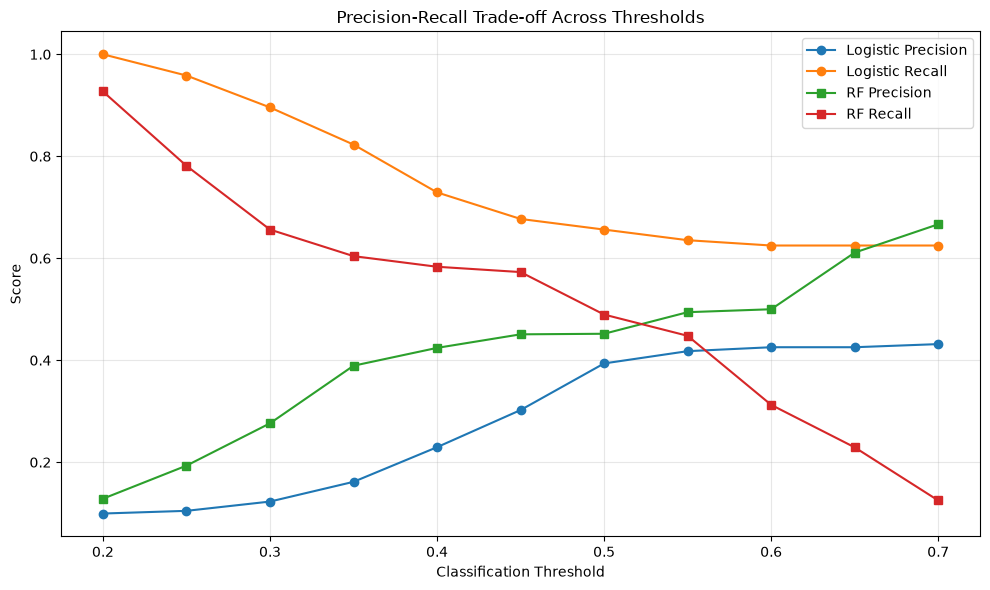

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    logistic_threshold_results["Threshold"],
    logistic_threshold_results["Precision"],
    marker="o",
    label="Logistic Precision"
)

plt.plot(
    logistic_threshold_results["Threshold"],
    logistic_threshold_results["Recall"],
    marker="o",
    label="Logistic Recall"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Precision"],
    marker="s",
    label="RF Precision"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Recall"],
    marker="s",
    label="RF Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Precision-Recall Trade-off Across Thresholds"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Step 10.15 F1 Score Comparison

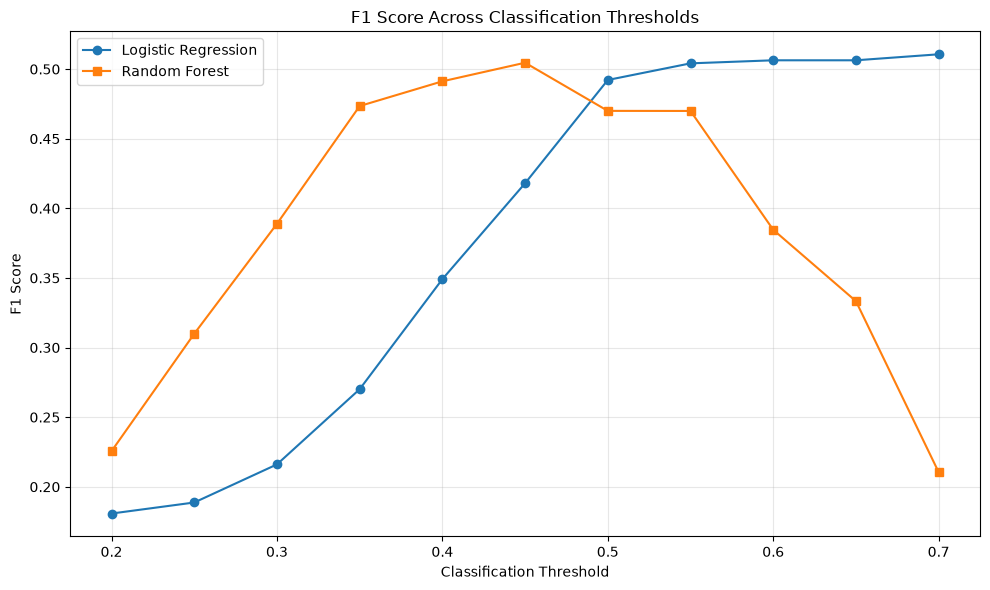

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    logistic_threshold_results["Threshold"],
    logistic_threshold_results["F1 Score"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["F1 Score"],
    marker="s",
    label="Random Forest"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")

plt.title(
    "F1 Score Across Classification Thresholds"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Step 10.16 Find Highest F1 Threshold

In [16]:
best_logistic_f1 = logistic_threshold_results.loc[
    logistic_threshold_results["F1 Score"].idxmax()
]

best_rf_f1 = rf_threshold_results.loc[
    rf_threshold_results["F1 Score"].idxmax()
]

print("Best Logistic Regression threshold by F1:")
print(best_logistic_f1)

print("\nBest Random Forest threshold by F1:")
print(best_rf_f1)

Best Logistic Regression threshold by F1:
Model        Logistic Regression
Threshold                    0.7
Accuracy                   0.885
Precision               0.431655
Recall                     0.625
F1 Score                0.510638
Name: 10, dtype: object

Best Random Forest threshold by F1:
Model        Random Forest
Threshold             0.45
Accuracy             0.892
Precision          0.45082
Recall            0.572917
F1 Score          0.504587
Name: 5, dtype: object


Step 10.17 Compare Best F1 Results

In [17]:
best_threshold_comparison = pd.DataFrame([
    best_logistic_f1,
    best_rf_f1
])

best_threshold_comparison

,Model,Threshold,Accuracy,Precision,Recall,F1 Score
10,Logistic Regression,0.70,0.885,0.431655,0.625000,0.510638
5,Random Forest,0.45,0.892,0.450820,0.572917,0.504587


Step 10.18 — Select Candidate Model

In [18]:
if (
    best_logistic_f1["F1 Score"]
    >
    best_rf_f1["F1 Score"]
):

    candidate_model_name = "Logistic Regression"
    candidate_threshold = best_logistic_f1["Threshold"]

else:

    candidate_model_name = "Random Forest"
    candidate_threshold = best_rf_f1["Threshold"]

print("Candidate Model:", candidate_model_name)
print("Candidate Threshold:", candidate_threshold)

Candidate Model: Logistic Regression
Candidate Threshold: 0.7


Step 10.19 — Generate Final Candidate Predictions

In [19]:
if candidate_model_name == "Logistic Regression":

    candidate_model = logistic_model
    candidate_probabilities = logistic_prob

else:

    candidate_model = random_forest_model
    candidate_probabilities = rf_prob


final_predictions = (
    candidate_probabilities >= candidate_threshold
).astype(int)

print("Final candidate model:", candidate_model_name)
print("Final candidate threshold:", candidate_threshold)

Final candidate model: Logistic Regression
Final candidate threshold: 0.7


Step 10.20 — Final Candidate Metrics

In [20]:
final_metrics = {
    "Model": candidate_model_name,
    "Threshold": candidate_threshold,
    "Accuracy": accuracy_score(
        y_test,
        final_predictions
    ),
    "Precision": precision_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        candidate_probabilities
    )
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

final_metrics_df

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7,0.885,0.431655,0.625,0.510638,0.799514


Step 10.21 — Final Confusion Matrix

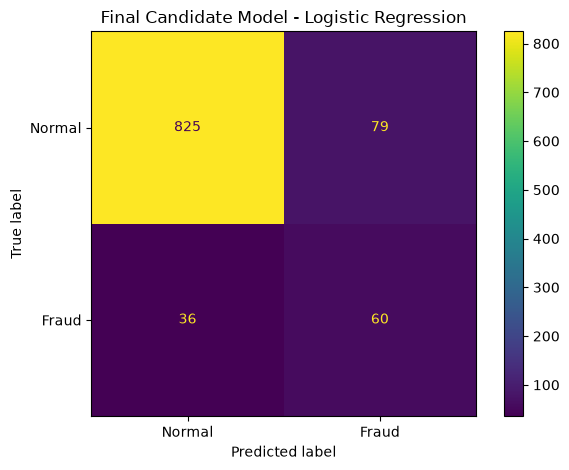

In [21]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot(
    values_format="d"
)

plt.title(
    f"Final Candidate Model - {candidate_model_name}"
)

plt.tight_layout()
plt.show()

Step 10.22 — Save Final Model

In [22]:
joblib.dump(
    candidate_model,
    "../models/final_fraud_model.pkl"
)

print("Final candidate model saved successfully.")

Final candidate model saved successfully.


Step 10.23 — Save Threshold

In [23]:
threshold_config = pd.DataFrame({
    "Model": [candidate_model_name],
    "Threshold": [candidate_threshold]
})

threshold_config.to_csv(
    "../models/final_model_threshold.csv",
    index=False
)

print("Threshold configuration saved successfully.")

Threshold configuration saved successfully.


Step 10.24 — Save Final Evaluation

In [24]:
final_metrics_df.to_csv(
    "../data/processed/final_model_metrics.csv",
    index=False
)

print("Final model metrics saved successfully.")

Final model metrics saved successfully.


Step 10.25 — Final Summary

In [25]:
print("=" * 60)
print("FINAL MODEL SELECTION SUMMARY")
print("=" * 60)

print(f"Model     : {candidate_model_name}")
print(f"Threshold : {candidate_threshold:.2f}")
print(f"Accuracy  : {final_metrics['Accuracy']:.4f}")
print(f"Precision : {final_metrics['Precision']:.4f}")
print(f"Recall    : {final_metrics['Recall']:.4f}")
print(f"F1 Score  : {final_metrics['F1 Score']:.4f}")
print(f"ROC-AUC   : {final_metrics['ROC-AUC']:.4f}")

FINAL MODEL SELECTION SUMMARY
Model     : Logistic Regression
Threshold : 0.70
Accuracy  : 0.8850
Precision : 0.4317
Recall    : 0.6250
F1 Score  : 0.5106
ROC-AUC   : 0.7995


## Final Model Selection

Multiple classification thresholds were evaluated for Logistic Regression and Random Forest to study the trade-off between precision and recall.

The default threshold of 0.50 was first evaluated, followed by threshold analysis from 0.20 to 0.70.

F1 Score was used as the primary selection criterion for identifying a candidate model and threshold because it balances precision and recall. The selected threshold was then used to generate the final candidate predictions and confusion matrix.

The final candidate model and its classification threshold were saved for use in the subsequent prediction and deployment stages.

Model selection in this project should be interpreted in the context of fraud-detection requirements, where both missed fraud cases and false alerts have practical implications.